In [32]:
import pandas as pd
from torchvision import transforms
from keras import models, layers, optimizers
from keras.datasets import mnist, cifar10
import matplotlib.pyplot as plt

In [15]:
train, test = mnist.load_data()

In [37]:
def create_model(alpha, train):
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=train[0].shape[1:3]))
    model.add(layers.Dense(units=256, activation='relu'))
    model.add(layers.Dense(units=128, activation='relu'))
    # First hidden layer
    model.add(layers.Dropout(rate=0.4))
    p = len(set(train[1].tolist()))
    model.add(layers.Dense(units=p, activation='softmax'))
    model.compile(optimizer=optimizers.Adam(learning_rate=alpha),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [39]:
def custom_model(train, lrate, hidden_units, act_fct_hidden, act_fct_output, drop_rate, metrics):
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=train[0].shape[1:3]))
    for units in hidden_units:
        model.add(layers.Dense(units=units, activation=act_fct_hidden))
        model.add(layers.Dropout(rate=drop_rate))
    p = len(set(train[1].tolist()))
    model.add(layers.Dense(units=p, activation=act_fct_output))
    model.compile(optimizer=optimizers.Adam(learning_rate=lrate),
                  loss='sparse_categorical_crossentropy',
                  metrics=metrics)
    return model

Epoch 1/50
12/12 [==============================] - 3s 213ms/step - loss: 87.2820 - accuracy: 0.5783 - val_loss: 9.5728 - val_accuracy: 0.8430
Epoch 2/50
12/12 [==============================] - 1s 115ms/step - loss: 8.3465 - accuracy: 0.8311 - val_loss: 2.5893 - val_accuracy: 0.8992
Epoch 3/50
12/12 [==============================] - 1s 113ms/step - loss: 2.5524 - accuracy: 0.8478 - val_loss: 1.0598 - val_accuracy: 0.8982
Epoch 4/50
12/12 [==============================] - 1s 112ms/step - loss: 1.3691 - accuracy: 0.8232 - val_loss: 0.7402 - val_accuracy: 0.8839
Epoch 5/50
12/12 [==============================] - 1s 114ms/step - loss: 0.9959 - accuracy: 0.8111 - val_loss: 0.6380 - val_accuracy: 0.8873
Epoch 6/50
12/12 [==============================] - 1s 112ms/step - loss: 0.8523 - accuracy: 0.8309 - val_loss: 0.5740 - val_accuracy: 0.8938
Epoch 7/50
12/12 [==============================] - 2s 113ms/step - loss: 0.7541 - accuracy: 0.8434 - val_loss: 0.5284 - val_accuracy: 0.9046
Epoch

[0.28616613149642944, 0.9559000134468079]

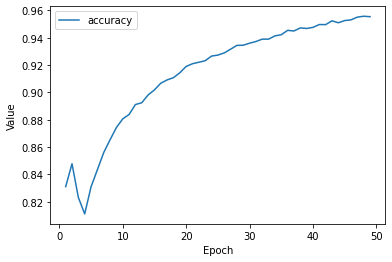

In [42]:
learning_rate = 0.003
epochs = 50
batch_size = 4000
validation_split = 0.2

model = custom_model(train, learning_rate, [512], 'relu', 'softmax', 0.4, ['accuracy'])
epochs, hist = train_model(model, train[0], train[1], epochs, batch_size, validation_split)

plot_curve(epochs, hist, ['accuracy'])
model.evaluate(x=test[0], y=test[1], batch_size=batch_size)

In [17]:
def train_model(model, train_data, train_targets, epochs, batch_size=None, validation_split=0.1):
    history = model.fit(x=train_data, y=train_targets, batch_size=batch_size,
                        epochs=epochs, shuffle=True, validation_split=validation_split)
    epochs=history.epoch
    hist = pd.DataFrame(history.history)
    return epochs, hist

In [35]:
def plot_curve(epochs, hist, list_of_metrics):
  plt.figure()
  plt.xlabel("Epoch")
  plt.ylabel("Value")

  for m in list_of_metrics:
    x = hist[m]
    plt.plot(epochs[1:], x[1:], label=m)

  plt.legend()

In [38]:
learning_rate = 0.003
epochs = 50
batch_size = 4000
validation_split = 0.2

model = create_model(learning_rate, train)
epochs, hist = train_model(model, train[0], train[1], epochs, batch_size, validation_split)

plot_curve(epochs, hist, ['accuracy'])
model.evaluate(x=test[0], y=test[1], batch_size=batch_size)

Epoch 1/50
12/12 [==============================] - 2s 100ms/step - loss: 33.6237 - accuracy: 0.4966 - val_loss: 1.5063 - val_accuracy: 0.6919
Epoch 2/50
12/12 [==============================] - 1s 76ms/step - loss: 1.8093 - accuracy: 0.4505 - val_loss: 1.2633 - val_accuracy: 0.5557
Epoch 3/50
12/12 [==============================] - 1s 74ms/step - loss: 1.4032 - accuracy: 0.5085 - val_loss: 0.9272 - val_accuracy: 0.6906
Epoch 4/50
12/12 [==============================] - 1s 76ms/step - loss: 1.1786 - accuracy: 0.5980 - val_loss: 0.7546 - val_accuracy: 0.7804
Epoch 5/50
12/12 [==============================] - 1s 75ms/step - loss: 1.0244 - accuracy: 0.6651 - val_loss: 0.6195 - val_accuracy: 0.8246
Epoch 6/50
12/12 [==============================] - 1s 83ms/step - loss: 0.9090 - accuracy: 0.7106 - val_loss: 0.5433 - val_accuracy: 0.8579
Epoch 7/50
12/12 [==============================] - 1s 74ms/step - loss: 0.8264 - accuracy: 0.7435 - val_loss: 0.4839 - val_accuracy: 0.8739
Epoch 8/50



 Evaluate the new model against the test set:
3/3 [==============================] - 0s 29ms/step - loss: 0.3278 - accuracy: 0.9527


[0.3278045058250427, 0.9527000188827515]

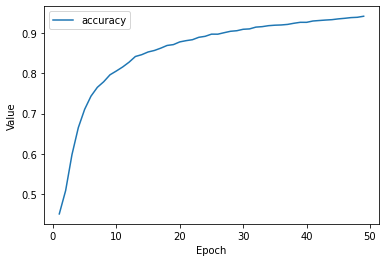

In [41]:
metric_to_plot = ['accuracy']
plot_curve(epochs, hist, list_of_metrics_to_plot)

print("\n Evaluate the new model against the test set:")
model.evaluate(x=test[0], y=test[1], batch_size=batch_size)

In [33]:
model.evaluate(x=test[0], y=test[1], batch_size=batch_size)

3/3 [==============================] - 0s 23ms/step - loss: 0.3169 - accuracy: 0.9456


[0.31694409251213074, 0.9455999732017517]